# GYPAETUS · transonic design gate

An assumption-explicit screen for a fuel-inclusive **≤55 lb (24.94758035 kg)** air-breathing aircraft, accelerating **Mach 0.8 → 1.0** in level or climbing flight. All internal values use SI.

**Restart Kernel and Run All before interpreting any result.** The model contains illustrative drag and engine maps. Numerical candidates are not validated aircraft designs. The generated conclusion at the end refers only to this run.

In [1]:
from pathlib import Path
import sys
import os
ROOT = Path.cwd()
if not (ROOT / 'gypaetus').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'gypaetus').is_dir(), 'Open this notebook from the repository or notebooks directory'
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.mplconfig'))
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
from dataclasses import asdict, replace
from IPython.display import Image, Markdown, display
from io import BytesIO
from gypaetus import Aircraft, Engine, Mission, DRAG_CASES, run_case
from gypaetus.atmosphere import atmosphere
from gypaetus.constants import MASS_LIMIT_KG
from gypaetus.cli import save_case
from gypaetus.estimates import runway_estimates
from gypaetus.plots import plot_case, plot_drag_cases, plot_pass_fail
from gypaetus.sweep import SweepGrid, run_sweep, save_sweep, conclusion
OUTPUT = ROOT / 'results'
OUTPUT.mkdir(exist_ok=True)
def show(fig):
    image = BytesIO()
    fig.savefig(image, format="png", dpi=130)
    display(Image(data=image.getvalue()))
    plt.close(fig)


## Assumptions first
The following page is loaded from the repository, so the notebook and written rules stay aligned.

In [2]:
display(Markdown((ROOT / 'docs' / 'assumptions.md').read_text()))

# Assumptions and design-gate rules

Read these rules before interpreting any result. All performance maps and design
limits supplied here are hypotheses. There is no measured GYPAETUS data in this
repository and no calibrated engine or aerodynamic model.

## 1. Scope, units, and mass

- SI internally: kg, m, s, N, Pa, K; angles are explicitly suffixed `_deg` or `_rad`.
  Mach, lift coefficients and drag coefficients are dimensionless.
- “25 kg / 55 lb” is ambiguous because 55 lb = **24.94758035 kg**, not 25 kg.
  The gate enforces the stricter value. Pounds mean mass; `N_PER_LBF` is separate.
- Initial mass = empty mass + usable fuel. Empty mass includes the installed
  engine, inlet, nozzle, tanks, avionics, control system, structure, and any
  unusable fuel. There is no free engine mass or uncounted hardware allowance.
- Initial conditions are at Mach 0.8. Fuel used for takeoff, climb, and acceleration
  to Mach 0.8 is outside this mission. A gate pass does not prove takeoff mass is
  under the cap or that the aircraft can reach these initial conditions.
- Air-breathing propulsion only. No rocket boost, stored oxidizer, launch energy,
  downhill flight path, or gravitational acceleration from descent is credited.
- Still, dry standard air; no wind, gusts or atmospheric uncertainty model.

## 2. What “pass” means

`gate_pass` is true only when the integration completes the **entire Mach
0.8→1.0 interval** within 120 s (configurable) and every check below passes:

1. Initial total mass ≤24.94758035 kg; fuel burn subsequently reduces mass.
2. No descent: prescribed flight-path angle γ is 0–10°, with nondecreasing altitude.
3. Installed net thrust exceeds drag over the evaluated path. The default
   numerical force margin is 0.01 N, chosen to reject equilibrium/stagnation.
4. Tangential accelerating force `T − D − mg sin(γ)` also meets that margin.
   For level flight this reduces to `T − D`. Positive excess thrust alone does
   not guarantee acceleration in a climb.
5. Fuel never becomes negative. Fuel exhaustion before completion fails.
6. Required `CL ≤ 0.60`, an assumed transonic stall/buffet limit.
7. Dynamic pressure `q ≤ 65,000 Pa`, an assumed structural screening limit.

Reaching exactly Mach 1 completes the numerical gate. It is **not supersonic
endurance**. `endurance_pass` separately requires accelerating to Mach 1.01,
then maintaining that Mach in level flight for five seconds with usable fuel
and sufficient thrust. Both are configurable. For a climbing entry, leveling
off is idealized as instantaneous; maneuver loads and transition trim are omitted.
The acceleration budget is shared by the Mach 1 gate and acceleration to the
hold condition. Hold time is additional. Disabling the hold produces an
unevaluated result, not a pass.

Failure to accelerate does not by itself predict a dive: the aircraft might
maintain level flight at a lower speed. This model stops the prescribed run;
it does not simulate pilot recovery, a glide, or a descent.

## 3. Atmosphere

The dry U.S. Standard Atmosphere 1976 lower layers supply temperature, pressure,
density, viscosity, and local sound speed for **geometric altitude 0–20 km**.
Geometric altitude `z` is converted to geopotential height
`H = Re z / (Re + z)` using `Re = 6,356,766 m`.

- Up to H=11,000 m: `T = 288.15 − 0.0065 H`; pressure follows the hydrostatic
  ideal-gas lapse-rate equation from 101,325 Pa.
- Above H=11,000 m: T=216.65 K and pressure decays exponentially.
- `ρ = p/(R T)`, `a = sqrt(1.4 R T)`, `R = 287.05287 J/(kg K)`.
- Sutherland viscosity: reference 1.716×10⁻⁵ Pa·s at 273.15 K, S=110.4 K.

Mach is always `V/a(z)`, with V true airspeed. In a climb, both atmosphere and
Mach are recalculated from current altitude. Integration stops at 19,900 m to
keep numerical solver stages inside the 20 km atmosphere domain. No extrapolation
is permitted by the public atmosphere or engine functions.

## 4. Lift and drag

Straight, unbanked, prescribed-γ point-mass flight assumes the aircraft can trim.
Thrust is aligned with velocity and has no normal component. No pitch dynamics,
turn loads, or changing flight-path angle is solved.

```
q  = ½ ρ V²
L  = mg cos(γ)              # L = mg for level flight
CL = L / (q S)
CD = CD_parasite + CL²/(π e AR) + CD_wave + CD_trim
D  = q S CD
```

All coefficients use **wing planform area S**. Default AR=3, e=0.75,
trim CD=0.002. Effective chord is `sqrt(S/AR)`, which assumes an equivalent
rectangular planform, not an actual tapered wing geometry.

| Drag assumption | CD0 at reference Reynolds number | Peak wave CD | Rise onset Mach |
| --- | ---: | ---: | ---: |
| Optimistic | 0.016 | 0.018 | 0.82 |
| Baseline | 0.022 | 0.035 | 0.78 |
| Pessimistic | 0.030 | 0.060 | 0.74 |

Wave drag rises via smoothstep `3x²−2x³`, where x spans onset to the peak at
Mach 1.02. Beyond the peak it decays as `0.65 + 0.35 exp(−((M−1.02)/0.16)²)`
times the peak coefficient. This is an **invented sensitivity family**, not a
published transonic polar. It represents a drag rise rather than a constant CD.
No claimed confidence interval or probability attaches to these three curves.

Reynolds number is `ρ V chord/μ`. The viscous share (default 65%) of CD0 is
scaled by `(Re/4e6)^−0.2`; the remaining 35% is unchanged. This is a simple
turbulent-friction sensitivity, not a transition/separation/compressibility model.
It does not validate extrapolation to a particular small wing.

Wave CD is additionally multiplied by
`area_rule_factor × (10/slenderness)²`, with both default factors giving unity.
This allows shape sensitivity only. It does not compute an area distribution,
an area-rule optimum, shock interactions, or actual wave drag from CAD.

## 5. Engine and fuel map

The default is a turbine surrogate with a **450 N sea-level static uninstalled
net-thrust rating**, TSFC=4×10⁻⁵ kg/(N·s), installation multiplier 0.85, and
altitude scaling `(ρ/ρSL)^0.75`. These are editable assumptions, not a named
engine's specifications. The domain is Mach 0–1.2 and geometric altitude 0–20 km.

| Mach knot | 0 | 0.4 | 0.8 | 1.0 | 1.2 |
| --- | ---: | ---: | ---: | ---: | ---: |
| Turbojet speed multiplier | 1.00 | 0.97 | 0.90 | 0.84 | 0.79 |
| Turbofan speed multiplier | 1.00 | 0.90 | 0.76 | 0.66 | 0.58 |

Linear interpolation connects knots. Uninstalled thrust equals bench rating
times altitude factor, speed factor and throttle. Installed thrust is 85% of
that value by default; installation loss does **not** reduce fuel flow.
The map already represents net thrust: do not subtract ram drag again.

Fuel flow is uninstalled thrust times the base TSFC and
`(1+0.15M) sqrt(T/288.15) (1+0.2(1−throttle))`. Throttle=0 models engine-off,
with zero thrust and fuel flow; idle, spool dynamics, thermal limits, inlet
unstart, and fuel scheduling are absent. The same configurable TSFC parameter
is available for each class; no measured efficiency comparison is implied.

`ramjet_assist` retains the turbojet core and adds a hypothetical assist term
starting above Mach 0.9, reaching the specified assist fraction at Mach 1.2.
Assist thrust scales with density and throttle, and assist fuel uses 1.5 times
core TSFC. This is only an interface/sensitivity placeholder; no real ramjet
operation at these speeds is asserted. A ramjet-only class is rejected.

## 6. Equations, integration, and numerical evidence

```
dV/dt     = (T − D)/m − g sin(γ)
dfuel/dt  = −fuel_flow
dz/dt     = V sin(γ)
m         = empty_mass + fuel
Ps        = (T − D) V / (mg)
```

Net engine thrust already accounts for propulsion momentum flux. An additional
`V dm/dt` term would double-count the open-system propulsion contribution.
Specific excess power Ps is split between climbing and kinetic energy change:
`Ps = dz/dt + V(dV/dt)/g`. Thus a positive Ps in a climb need not mean increasing V.

SciPy RK45 uses relative tolerance 10⁻⁸, absolute tolerance 10⁻¹⁰, and default
maximum step 0.25 s (never above 0.5 s). Terminal events detect Mach completion,
fuel exhaustion, insufficient accelerating force, CL/q limits and altitude limit.
Post-integration checks use solver nodes, ≤0.05 s samples, and a Mach grid with
nominal spacing ≤0.0002 along a monotonic trajectory. This is numerical evidence,
not a mathematical guarantee of positivity at every real-valued Mach. Inputs with
sharper calibrated features require a smaller step and renewed convergence checks.
Tiny fuel-event roundoff is clamped to zero; fuel exhaustion is still a stop event.

The hold uses level flight with throttle selected to balance drag, bounded by
the mission's available throttle. Decreasing fuel mass updates lift, drag, and
fuel flow. It does not reuse initial fuel or ignore the acceleration to Mach 1.01.

Dashed/dotted thrust and drag curves over the full gate are evaluated at the
**initial mass and altitude**. Solid curves cover only the integrated trajectory.
For climbs the entry-condition curves do not represent the later atmosphere.

## 7. Sweep, robustness, and unresolved design work

The default Cartesian grid covers S=(0.08,0.12,0.18) m², bench thrust=(300,450,600) N,
fuel=(1,3) kg, empty mass=(18,21) kg, altitude=(0,3000,6000) m and three drag cases.
That is 108 parameter combinations ×3 assumed polars =324 runs. No independence
between engine thrust, engine mass, tank volume, wing mass or geometry is physically
established by this grid. It is a search of assumptions, not a catalogue of aircraft.

The table distinguishes optimistic-only, baseline-sensitive, all-three-polar
and all-three-failed combinations. An all-three-polar pass means robustness
**only to this selected drag family**, not overall design robustness. The pass/fail
maps use installed T/W at Mach 0.8 and initial W/S. Coincident coordinates with
different outcomes are marked mixed; they are not hidden by overplotting.

The q cap is a configurable screen, not a calculated structural allowable. A
separate flag requests flutter analysis at q≥40 kPa or Mach≥0.85. There is no
flutter solver or validated flutter boundary. Trim drag is budgeted, but tail
volume, control authority, center-of-gravity travel, static margin and stability
remain unresolved and are flagged on every run.

Ground-roll estimates assume a stated landing CLmax=1.2, liftoff=1.2Vs,
approach=1.3Vs, constant representative takeoff acceleration at 0.7 liftoff speed
with half the weight on the wheels, rolling friction=0.03, and landing braking
friction=0.3. Landing roll ignores aerodynamic drag and reverse thrust. They use
the transonic-entry mass and runway altitude zero by default; they do not include
takeoff fuel, flare, reaction, obstacles, slope, wind, ground effect or reserves.
These estimates do not clear runway feasibility.

## 8. Reproducibility

Record inputs with each result. Run tests and execute the entire notebook with a
fresh kernel. The final notebook cell builds its conclusion from the freshly
computed table; never hand-edit that conclusion to claim a pass. The supplied
fresh-kernel script clears old outputs and fails on any cell error. Do not replace
missing empirical inputs with authoritative-looking constants.



## Atmosphere and editable inputs
Altitude is geometric. Mach uses the local speed of sound. Empty mass includes every installed component; initial fuel is what remains at Mach 0.8.

,altitude_m,temperature_k,pressure_pa,density_kg_m3,sound_speed_m_s,viscosity_pa_s,sound_speed_gradient_s_inv
0,0,288.150000,101325.000000,1.225000,340.293988,0.000018,-0.003838
1,3000,268.659198,70121.144068,0.909254,328.583553,0.000017,-0.003971
2,6000,249.186776,47217.617099,0.660111,316.451720,0.000016,-0.004120
3,11000,216.773513,22699.936837,0.364801,295.153591,0.000014,-0.004410
4,20000,216.650000,5529.300574,0.088910,295.069494,0.000014,0.000000


,mass_kg,cap_kg,within_mass_cap
0,23,24.94758,True


sea_level_static_thrust_n         450
tsfc_kg_n_s                   0.00004
installed_factor                 0.85
altitude_exponent                0.75
propulsion_class             turbojet
assist_fraction                   0.3
Name: Engine assumptions, dtype: object

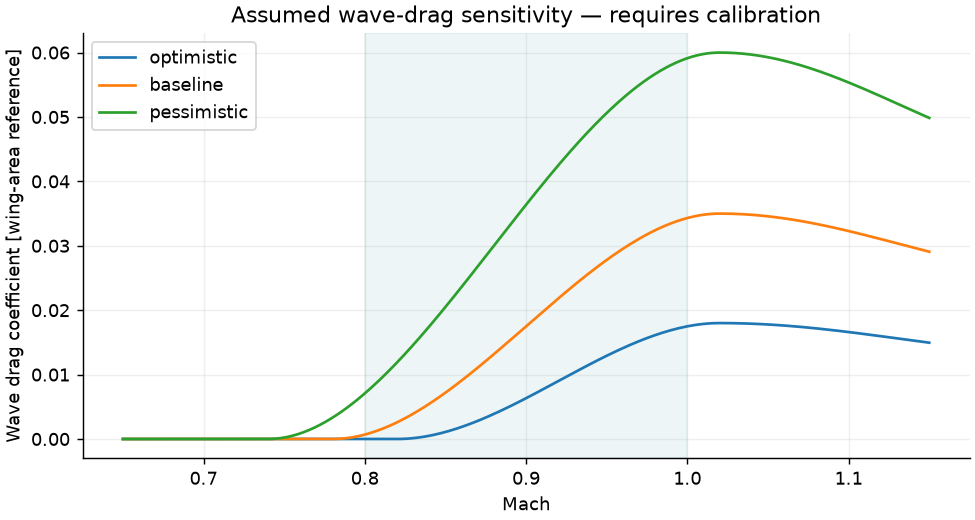

In [3]:
atmosphere_table = pd.DataFrame([{'altitude_m': z, **asdict(atmosphere(z))} for z in (0, 3000, 6000, 11000, 20000)])
display(atmosphere_table)
aircraft = Aircraft(empty_mass_kg=20, fuel_mass_kg=3, wing_area_m2=0.12)
engine = Engine(sea_level_static_thrust_n=450, installed_factor=0.85)
mission = Mission(altitude_m=3000, gamma_deg=0, hold_mach=1.01, hold_seconds=5)
polar = DRAG_CASES['baseline']
display(pd.DataFrame([{'mass_kg': aircraft.total_mass_kg, 'cap_kg': MASS_LIMIT_KG,
                       'within_mass_cap': aircraft.total_mass_kg <= MASS_LIMIT_KG}]))
display(pd.Series(asdict(engine), name='Engine assumptions'))
show(plot_drag_cases(aircraft, OUTPUT))

## Single case: show the actual trajectory

For level flight, $L=mg$, $C_L=L/(qS)$, $m\dot V=T-D$, and $\dot m=-\dot m_f$.
For a prescribed climb, $L=mg\cos\gamma$, $m\dot V=T-D-mg\sin\gamma$, and $\dot z=V\sin\gamma$.

The solid curves stop at the terminal event. Gray reference curves keep entry mass and altitude fixed and do not imply that a failed run reached Mach 1. The default baseline case demonstrates a thrust shortfall.

gate_pass                                                                         False
endurance_pass                                                                    False
termination                                                   insufficient_acceleration
failure_reasons                                insufficient_acceleration;reached_mach_1
endurance_termination                                                       gate_failed
drag_case                                                                      baseline
empty_mass_kg                                                                        20
initial_fuel_kg                                                                       3
initial_mass_kg                                                                      23
wing_area_m2                                                                       0.12
altitude_m                                                                         3000
gamma_deg                       

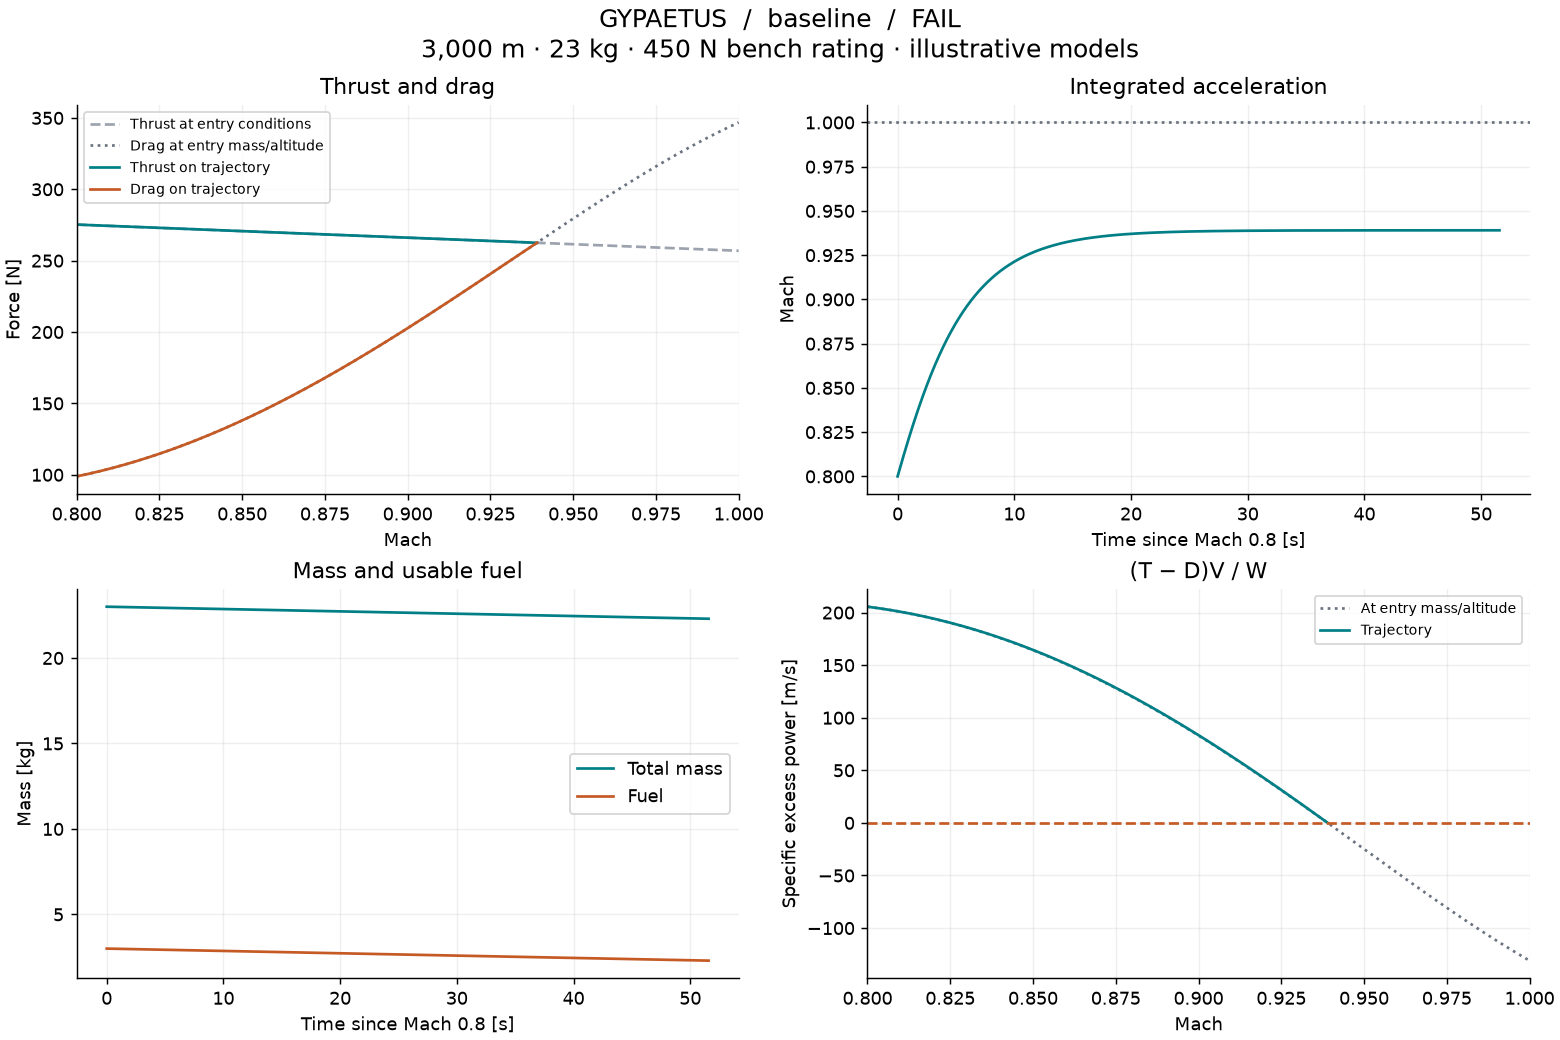

In [4]:
case = run_case(aircraft, engine, polar, mission)
save_case(case, OUTPUT / 'single_case')
display(pd.Series(case.summary, name='Single-case result'))
show(plot_case(case, OUTPUT / 'single_case'))

## Compare the three drag assumptions
The same mass, engine and mission are used for each curve. An optimistic-only win is reported explicitly by the sweep.

In [5]:
sensitivity = [run_case(aircraft, engine, p, mission).summary for p in DRAG_CASES.values()]
display(pd.DataFrame(sensitivity)[['drag_case', 'gate_pass', 'termination', 'final_mach',
    'min_excess_thrust_n', 'endurance_pass', 'failure_reasons']])

,drag_case,gate_pass,termination,final_mach,min_excess_thrust_n,endurance_pass,failure_reasons
0,optimistic,True,target_reached,1.000000,45.096203,True,
1,baseline,False,insufficient_acceleration,0.939054,0.010000,False,insufficient_acceleration;reached_mach_1
2,pessimistic,False,insufficient_acceleration,0.870227,0.010000,False,insufficient_acceleration;reached_mach_1


## Supersonic hold and climb examples
A small-wing, higher-thrust candidate illustrates the separate five-second Mach 1.01 hold. These parameters do not assert that a 600 N installed engine fits the empty-mass budget. The climb uses the same equations with a positive flight-path angle.

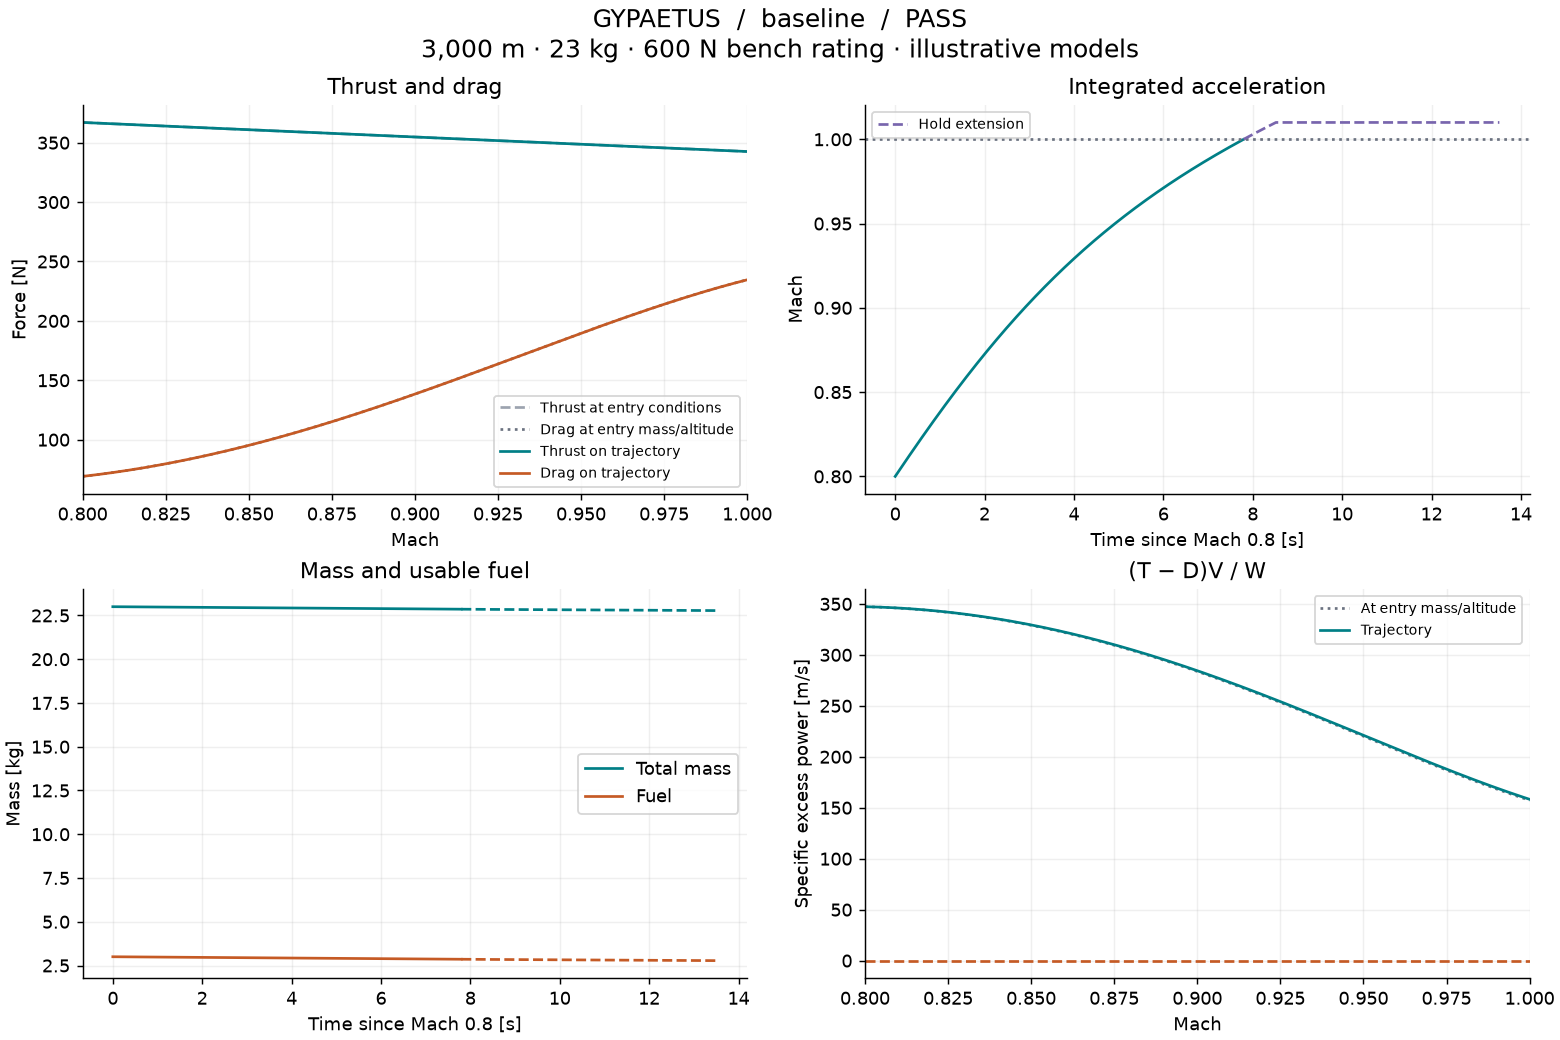

,example,gate_pass,endurance_pass,termination,failure_reasons,endurance_termination,drag_case,empty_mass_kg,initial_fuel_kg,initial_mass_kg,...,max_q_pa,review_flags,reached_mach_1,mass_within_limit,fuel_nonnegative,never_descends,positive_excess_thrust,positive_acceleration,cl_within_limit,q_within_limit
0,level hold,True,True,target_reached,,hold_complete,baseline,20,3,23,...,49084.800848,uncalibrated_drag_and_engine;trim_stability_co...,True,True,True,True,True,True,True,True
1,3 degree climb,True,True,target_reached,,hold_complete,baseline,20,3,23,...,48274.142070,uncalibrated_drag_and_engine;trim_stability_co...,True,True,True,True,True,True,True,True


stall_speed_m_s                                                  61.934921
liftoff_speed_m_s                                                74.321905
approach_speed_m_s                                               80.515398
takeoff_ground_roll_m                                           131.240852
landing_ground_roll_m                                          1101.757353
assumption               Constant representative takeoff acceleration; ...
Name: Indicative runway estimates, dtype: object

In [6]:
candidate_aircraft = replace(aircraft, wing_area_m2=0.08)
candidate_engine = replace(engine, sea_level_static_thrust_n=600)
candidate = run_case(candidate_aircraft, candidate_engine, polar, mission)
save_case(candidate, OUTPUT / 'hold_example')
show(plot_case(candidate, OUTPUT / 'hold_example'))
climb = run_case(candidate_aircraft, candidate_engine, polar, replace(mission, gamma_deg=3))
display(pd.DataFrame([{'example': name, **result.summary} for name, result in [('level hold', candidate), ('3 degree climb', climb)]]))
display(pd.Series(runway_estimates(candidate_aircraft, candidate_engine, polar), name='Indicative runway estimates'))

## Search the design space
The default grid contains 108 parameter combinations, each evaluated against three polars (324 runs). A pass includes the assumed dynamic-pressure screen. Every failed case remains in the export with its reason. Change `SweepGrid` here to run a different search.

In [7]:
grid = SweepGrid()
results = run_sweep(grid, aircraft, engine, mission)
save_sweep(results, OUTPUT)
display(results.groupby(['altitude_m', 'drag_case']).agg(cases=('gate_pass', 'size'),
    gate_passes=('gate_pass', 'sum'), endurance_passes=('endurance_pass', 'sum')))
passing = results[results.gate_pass]
columns = ['design_id', 'drag_case', 'altitude_m', 'wing_area_m2', 'rated_thrust_n',
           'empty_mass_kg', 'initial_fuel_kg', 'initial_mass_kg', 'time_to_mach_1_s',
           'min_excess_thrust_n', 'endurance_pass', 'drag_sensitivity']
display(passing[columns])
print(f'Full passing table: {OUTPUT / "passing_cases.csv"}')

cases  gate_passes  endurance_passes
altitude_m drag_case                                        
0.0        baseline        36            0                 0
           optimistic      36            0                 0
           pessimistic     36            0                 0
3000.0     baseline        36            8                 8
           optimistic      36           24                24
           pessimistic     36            0                 0
6000.0     baseline        36           12                12
           optimistic      36           24                24
           pessimistic     36            4                 4

,design_id,drag_case,altitude_m,wing_area_m2,rated_thrust_n,empty_mass_kg,initial_fuel_kg,initial_mass_kg,time_to_mach_1_s,min_excess_thrust_n,endurance_pass,drag_sensitivity
3,D0002,optimistic,3000.0,0.08,300.0,18.0,1.0,19.0,16.848267,27.902546,True,optimistic_only
6,D0003,optimistic,6000.0,0.08,300.0,18.0,1.0,19.0,17.153157,35.359180,True,optimistic_only
12,D0005,optimistic,3000.0,0.08,300.0,21.0,1.0,22.0,19.667315,27.483447,True,optimistic_only
15,D0006,optimistic,6000.0,0.08,300.0,21.0,1.0,22.0,20.095472,34.734523,True,optimistic_only
21,D0008,optimistic,3000.0,0.08,300.0,18.0,3.0,21.0,18.720036,27.629948,True,optimistic_only
...,...,...,...,...,...,...,...,...,...,...,...,...
303,D0102,optimistic,6000.0,0.18,600.0,21.0,1.0,22.0,10.926921,54.376296,True,optimistic_only
309,D0104,optimistic,3000.0,0.18,600.0,18.0,3.0,21.0,11.563635,29.704695,True,optimistic_only
312,D0105,optimistic,6000.0,0.18,600.0,18.0,3.0,21.0,10.419408,54.473273,True,optimistic_only
318,D0107,optimistic,3000.0,0.18,600.0,21.0,3.0,24.0,13.254244,29.500997,True,optimistic_only


Full passing table: /Users/jeremiahmaysmei/Documents/ChatGPT/Gypaetus/results/passing_cases.csv


## Pass/fail maps
Installed thrust-to-weight at Mach 0.8 versus initial wing loading; one panel per altitude. Coincident points with differing outcomes receive a mixed marker. These are sampled combinations, not interpolated feasibility boundaries.

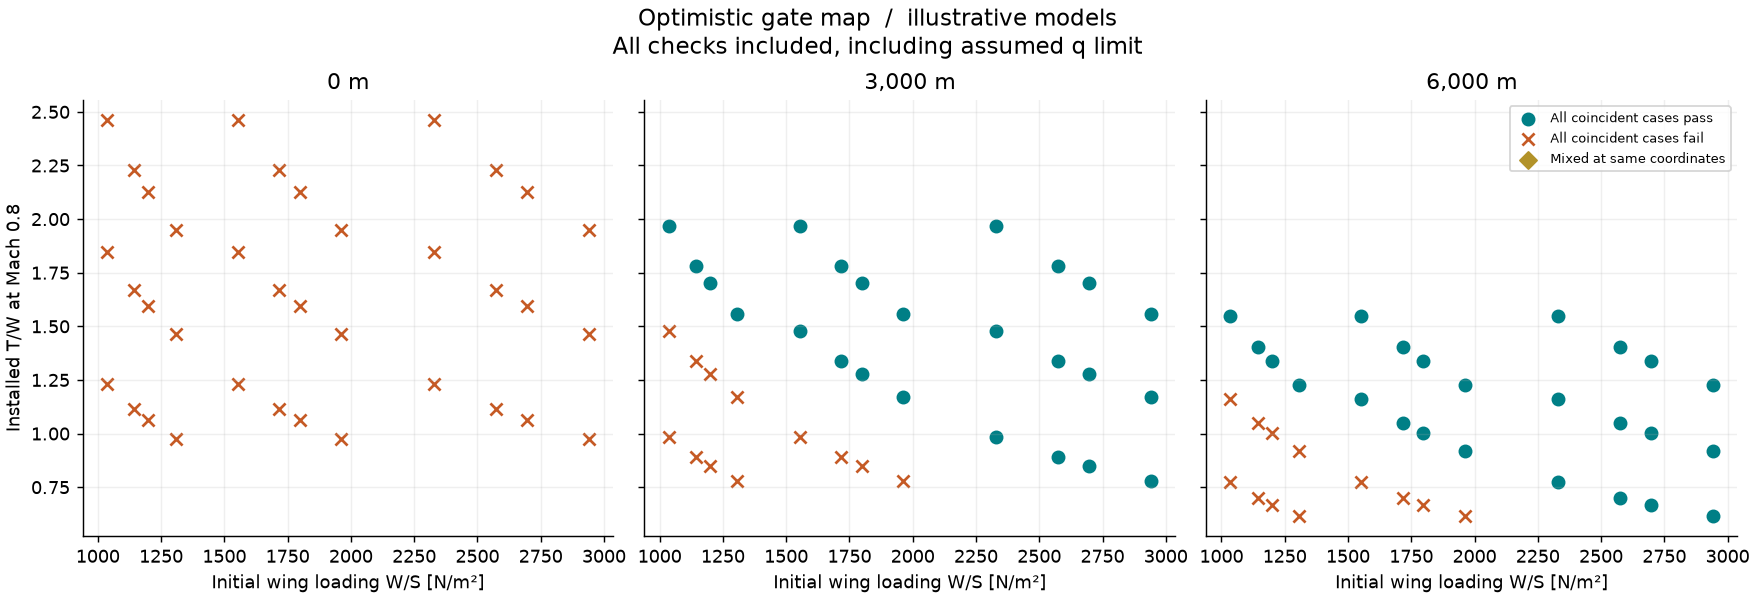

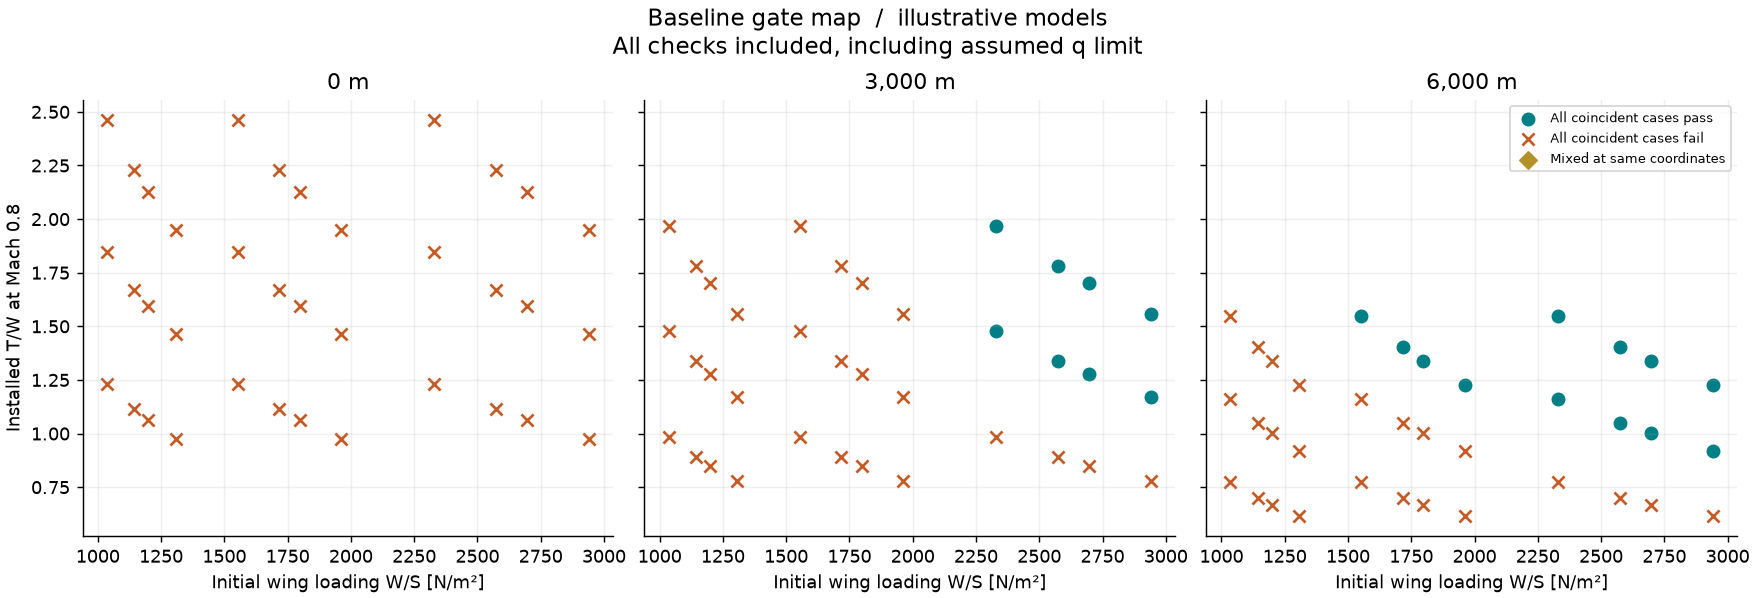

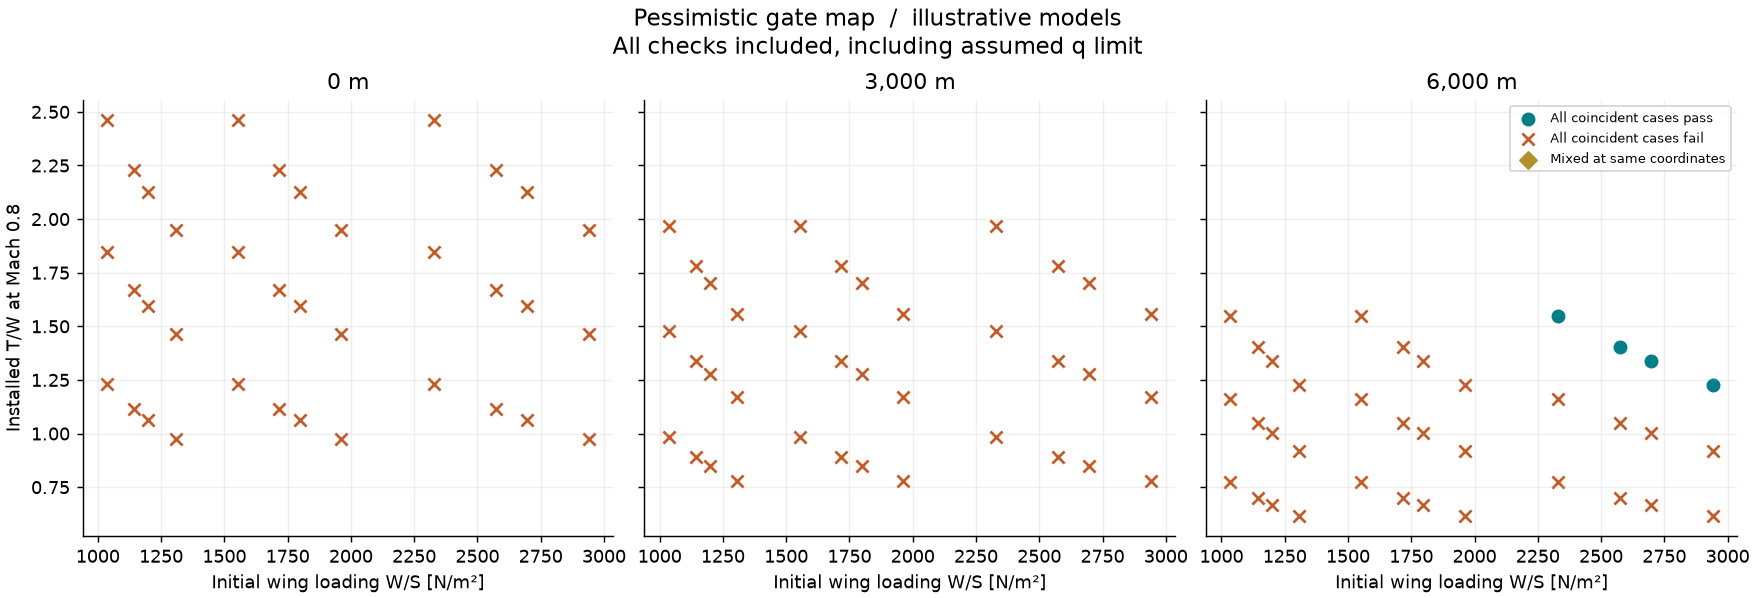

,design_id,drag_case,altitude_m,wing_area_m2,rated_thrust_n,empty_mass_kg,initial_fuel_kg,initial_mass_kg,time_to_mach_1_s,min_excess_thrust_n,endurance_pass,drag_sensitivity
79,D0027,baseline,6000.0,0.08,600.0,18.0,1.0,19.0,7.060512,108.371128,True,passes_all_three_assumed_polars
88,D0030,baseline,6000.0,0.08,600.0,21.0,1.0,22.0,8.213203,107.744848,True,passes_all_three_assumed_polars
97,D0033,baseline,6000.0,0.08,600.0,18.0,3.0,21.0,7.827199,107.963784,True,passes_all_three_assumed_polars
106,D0036,baseline,6000.0,0.08,600.0,21.0,3.0,24.0,8.991017,107.276450,True,passes_all_three_assumed_polars


In [8]:
for name in grid.drag_cases:
    show(plot_pass_fail(results, OUTPUT, name))
all_polar_candidates = results[(results.drag_case == 'baseline') &
    (results.drag_sensitivity == 'passes_all_three_assumed_polars')]
display(all_polar_candidates[columns])

## Design-gate conclusion
This paragraph is generated from the table above. It is not a manually selected success claim.

In [9]:
display(Markdown(conclusion(results)))
display(Markdown((ROOT / 'docs' / 'sources.md').read_text()))

Under the recorded assumptions, 72 of 324 drag-specific cases pass the Mach 0.8→1.0 gate. Of 108 distinct parameter combinations, 4 pass all three assumed drag polars, 28 pass only the optimistic polar, and 60 fail all three. 72 cases also completed the configured supersonic hold. An optimistic-only pass is not a supported design claim. Even an all-polar pass is a numerical candidate: the engine/drag maps, installed engine mass, structural limits, flutter, and trim/control remain unvalidated. These results do not establish that a buildable aircraft meets the gate.

# Model sources and provenance

The following primary references support the physical equations. They do **not**
validate this repository's engine multipliers, transonic drag curves, mass budget,
stall/buffet bound, dynamic-pressure limit or flutter flag.

- [U.S. Standard Atmosphere, 1976, NASA-TM-X-74335](https://ntrs.nasa.gov/citations/19770009539):
  basis for the lower-atmosphere hydrostatic layers, thermodynamic constants,
  geometric/geopotential conversion and transport-property approximation.
- [NASA Glenn: Drag Equation](https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/drag-equation/):
  reference-area convention and `D = CD ρV²S/2`.
- [NASA Glenn: Induced Drag Coefficient](https://www1.grc.nasa.gov/beginners-guide-to-aeronautics/induced-drag-coefficient/):
  `CDi = CL²/(π AR e)`. Its use here remains a low-order approximation across
  transonic flow, not an assertion that incompressible lifting-line theory is exact.
- [NASA Glenn: Turbojet Thrust](https://www.grc.nasa.gov/www/k-12/airplane/turbth.html):
  distinction between gross and net thrust, including incoming-flow momentum.
- [NASA Glenn: Specific Fuel Consumption](https://www.grc.nasa.gov/WWW/k-12/airplane/sfc.html):
  TSFC definition, `fuel_mass_flow = TSFC × thrust`, and dependence on conditions.

The Reynolds power-law sensitivity, smooth wave-drag shape, slenderness
multiplier, installed-thrust correction, engine speed/altitude/throttle factors,
ramjet-assist placeholder and ground-roll estimates are explicitly chosen
engineering simplifications. None is presented as data extracted from these sources.

Validation consists of atmosphere reference points, lift and energy balances,
fuel conservation, map behavior, rejection of invalid inputs, hard failure cases,
step-size convergence, sweep completeness, and fresh-kernel notebook execution.
Empirical validation remains outstanding.

